In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
max_features = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

print("Training samples:", len(x_train))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000


In [ ]:
def build_model(model_type):
    model = keras.Sequential()
    model.add(layers.Embedding(max_features, 128, input_length=max_len))

    if model_type == "RNN":
        model.add(layers.SimpleRNN(128))
    elif model_type == "LSTM":
        model.add(layers.LSTM(128))
    elif model_type == "GRU":
        model.add(layers.GRU(128))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
models = {}
histories = {}

for model_name in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_name}...")
    model = build_model(model_name)
    history = model.fit(x_train, y_train,
                        epochs=3,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=1)
    models[model_name] = model
    histories[model_name] = history


Training RNN...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 126ms/step - accuracy: 0.5386 - loss: 0.6867 - val_accuracy: 0.6098 - val_loss: 0.6555
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - accuracy: 0.7078 - loss: 0.5589 - val_accuracy: 0.7404 - val_loss: 0.5401
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 127ms/step - accuracy: 0.7380 - loss: 0.5225 - val_accuracy: 0.6424 - val_loss: 0.6657

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 145s 453ms/step - accuracy: 0.7677 - loss: 0.4719 - val_accuracy: 0.7830 - val_loss: 0.4548
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 454ms/step - accuracy: 0.8874 - loss: 0.2834 - val_accuracy: 0.8634 - val_loss: 0.3344
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 456ms/step - accuracy: 0.9224 - loss: 0.2061 - val_accuracy: 0.8550 - val_loss: 0.3505

Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 148s 463ms/step - accuracy: 0.7431 - loss: 0.5032 - val_accuracy: 0.8376 - val_loss: 0.3719
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 201s 460ms/step - accu

In [ ]:
results = {}

for model_name, model in models.items():
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results[model_name] = acc
    print(f"{model_name} Test Accuracy: {acc:.4f}")

RNN Test Accuracy: 0.6438
LSTM Test Accuracy: 0.8560
GRU Test Accuracy: 0.8704


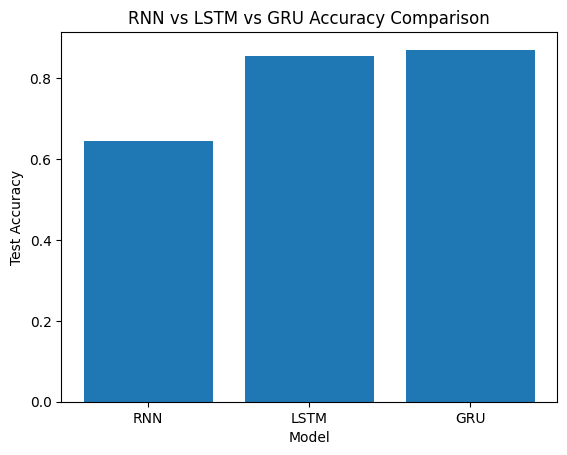

In [ ]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("RNN vs LSTM vs GRU Accuracy Comparison")
plt.show()